* 럭키백에 들어갈 수 있는 생선은 7개. 

* 럭키백에 들어간 생선의 크기, 무게 등이 주어졌을 때 7개 생선에 대한 확률을 출력한다.

* 변수: 길이, 높이, 두께, 대각선 길이, 무게

#### > 이웃의 클래스 비율을 확률로 출력한다면?

예를 들어 밑의 예시에서 x 주위에 가장 가까운 이웃 샘플 10개 중 3개가 사각형이므로, 샘플 x가 사각형일 확률은 30% 

scikit-learn의 k-최근접 이웃 분류기를 활용해보자

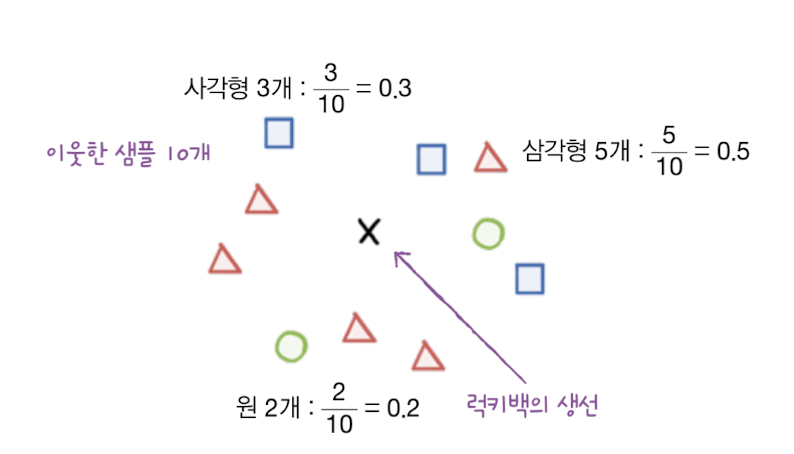

In [1]:
# 데이터 준비
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
# 생선 종류 확인
print(pd.unique(fish['Species']))

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [ ]:
# 데이터에서 species 열 제외하고 선택
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
print(fish_input[:5])

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [5]:
# 마찬가지로 타깃 데이터도 만들기
fish_target = fish['Species'].to_numpy()

In [6]:
# 훈련/테스트 세트 준비 및 표준화 전처리
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [7]:
# KNeighborsClassifier 모델 훈련한 뒤 점수 확인
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(n_neighbors=3) # 이웃수 = 3
kn.fit(train_scaled, train_target)

print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


### 다중분류
타깃 데이터에 2개 이상의 클래스가 포함된 문제

사이킷런에서는 문자열로 된 타깃값을 그대로 사용할 수 있다. 

이때 알파벳 순으로 순서가 매겨진다.

In [ ]:
# 아까 확인했던 것과 순서가 다르다
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [9]:
# 샘플의 타깃값 예측
print(kn.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [ ]:
# 사이킷런의 분류 모델은 predict_proba 메서드로 클래스별 확률값을 반환한다.
import numpy as np
proba = kn.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=4))  # 5번째 자리에서 반올림, 넷째자리까지 표기

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [ ]:
# 모델이 계산한 확률이 가장 가까운 이웃의 비율이 맞는지 네 번째 샘플로 확인
distances, indexes = kn.kneighbors(test_scaled[3:4])
print(train_target[indexes])

[['Roach' 'Perch' 'Perch']]


이웃은 Roach 1개, Perch 2개 (확률은 각각 0.3333, 0.6667)

이는 앞서 출력한 네번째 샘플의 클래스 확률과 같다.


하지만 이렇게 3개의 최근접 이웃을 사용하면 가능한 확률의 경우의 수가 너무 적다. 럭키백의 확률 이렇게 표시하는건 무리..

# 로지스틱 회귀
회귀이지만 분류 모델. 선형 회귀와 동일하게 선형 방정식을 학습한다.

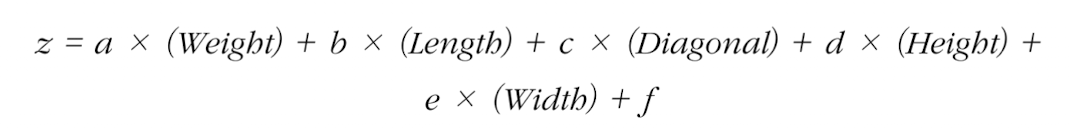

각 계수는 가중치이고, z는 어떤 값도 가능하다. 단, 확률이 되려면 0~1 사이의 값.

##### 시그모이드 함수(또는 로지스틱 함수)
-> z가 아주 큰 음수일 때 0이 되고, z가 아주 큰 양수일 때 1이 되도록 바꿀 수 있다.

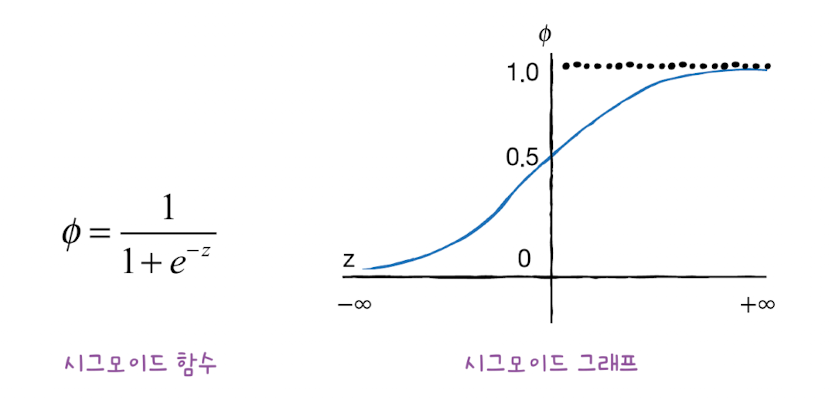

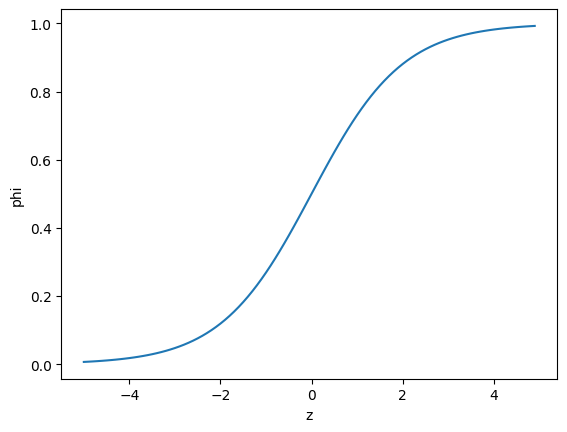

In [12]:
# 시그모이드 함수 그리기
import numpy as np
import matplotlib.pyplot as plt
z = np.arange(-5, 5, 0.1)
phi = 1 / (1 + np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

* 참고: 사이킷런은 0.5일 때 음성 클래스로 판단한다.

### 불리언 인덱싱
True, False 값을 전달해서 행을 선택한다.

In [ ]:
# 불리언 인덱싱의 예시
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [15]:
# 이진 분류 간단한 예시
# 도미와 방어에 대한 행만 골라내기
bs_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bs = train_scaled[bs_indexes]
target_bs = train_target[bs_indexes]

In [17]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bs, target_bs)

print(lr.predict(train_bs[:5]))
print(lr.predict_proba(train_bs[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']
[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [ ]:
# Bream: 음성 클래스, Smelt: 양성 클래스
print(lr.classes_)

['Bream' 'Smelt']


In [19]:
# 로지스틱 회귀가 학습한 계수 확인
print(lr.coef_, lr.intercept_)

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]


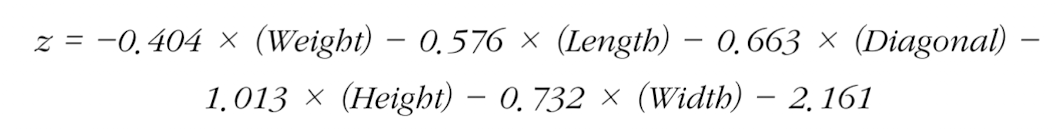

In [20]:
# 로지스틱 모델로 z값 계산하기
decisions = lr.decision_function(train_bs[:5])
print(decisions)

[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [ ]:
# 위의 z값들을 시그모이드 함수(expit())에 대입하면 확률을 얻을 수 있다
# predict_proba()의 두번째 열과 동일한 값. 즉 양성 클래스에 대한 z값을 반환
from scipy.special import expit
print(expit(decisions))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


### 로지스틱 회귀로 다중 분류 수행하기
#### LogisticRegression 클래스
* 반복적인 알고리즘을 사용. max_iter로 반복 횟수 지정 (기본값 100)
* 기본적으로 계수의 제곱을 규제한다(L2 규제) -> 매개변수 C : 작을 수록 규제가 커진다 (기본값 1)

In [22]:
# 7개 생선 데이터에 대한 다중 분류 모델 훈련
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)

print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [26]:
# 처음 5개 샘플에 대한 예측과 예측확률
print(lr.classes_)

print(lr.predict(test_scaled[:5]))

proba = lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [27]:
print(lr.coef_.shape, lr.intercept_.shape)

(7, 5) (7,)


열 5개: 5개의 특성을 사용

행 7개, intercept 7개
: 다중 분류는 클래스마다 z값을 하나씩 계산한다. 가장 높은 z값을 출력하는 클래스가 예측 클래스가 된다.

#### 다중분류는 소프트맥스 함수를 사용하여 7개의 z값을 확률로 변환한다.
(소프트맥스 함수는 여러 개의 선형 방정식의 출력값을 0~1 사이로 압축하고 전체 합이 1이 되도록 만든다. 이를 위해 지수함수를 사용해서, '정규화된 지수 함수'라고도 부른다.)

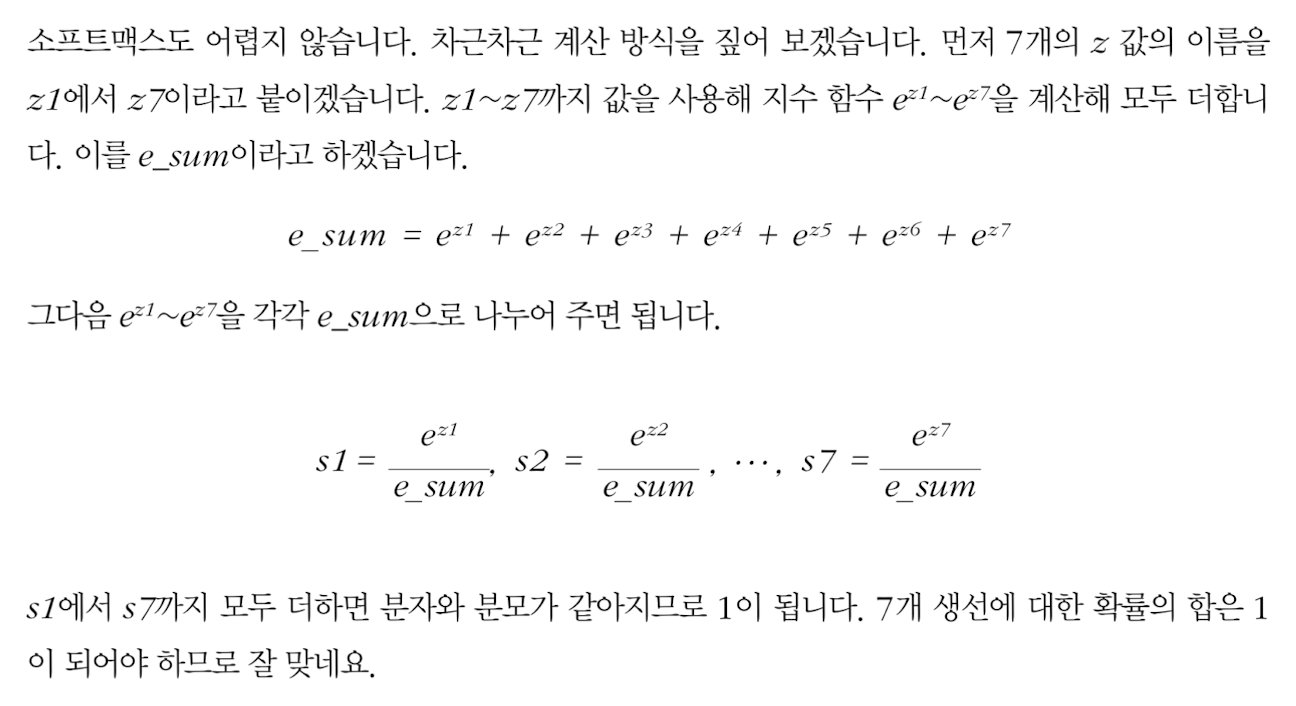

In [28]:
# 처음 5개 샘플에 대한 z1~z7값 구하기
decision = lr.decision_function(test_scaled[:5])
print(np.round(decision, decimals=2))

[[ -6.51   1.04   5.17  -2.76   3.34   0.35  -0.63]
 [-10.88   1.94   4.78  -2.42   2.99   7.84  -4.25]
 [ -4.34  -6.24   3.17   6.48   2.36   2.43  -3.87]
 [ -0.69   0.45   2.64  -1.21   3.26  -5.7    1.26]
 [ -6.4   -1.99   5.82  -0.13   3.5   -0.09  -0.7 ]]


In [ ]:
# softmax 함수를 통해 확률로 값 바꾸기
from scipy.special import softmax
proba = softmax(decision, axis=1)   # 각 행에 대해 계산
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


앞에서 구한 proba 배열과 값이 일치한다